# 01 — Análise Exploratória (EDA) da Série de Vendas

Objetivo: entender a série temporal de vendas, confirmar seus **componentes** (tendência, sazonalidade semanal e anual, efeito de feriados/promoções) e orientar a escolha e a configuração dos modelos.

> Dados gerados por `src/data/generate_synthetic.py` a partir de componentes interpretáveis — logo a série tem estrutura real de série temporal para os modelos aprenderem.

In [1]:
import sys; sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from src.data.generate_synthetic import generate_sales

df = generate_sales(days=1277, seed=42).set_index('date')
df.head()

,sales,promo,holiday
date,,,
2021-01-01,1452,0,1
2021-01-02,1349,0,0
2021-01-03,1072,0,0
2021-01-04,971,0,0
2021-01-05,855,0,0


## Série completa

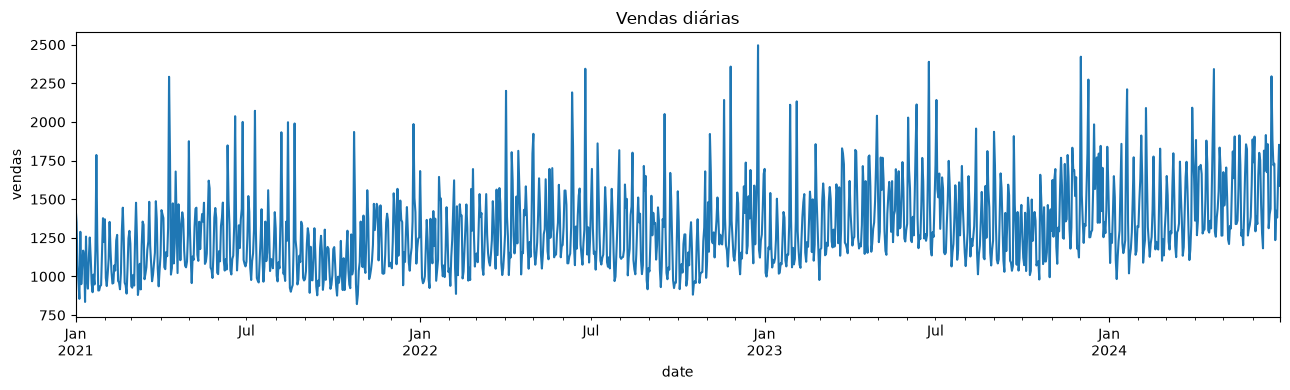

count    1277.000000
mean     1310.830070
std       270.648623
min       821.000000
25%      1110.000000
50%      1264.000000
75%      1459.000000
max      2496.000000
Name: sales, dtype: float64


In [2]:
df['sales'].plot(figsize=(13,4), title='Vendas diárias')
plt.ylabel('vendas'); plt.tight_layout(); plt.show()
print(df['sales'].describe())

## Decomposição sazonal (tendência + sazonalidade + resíduo)

Período semanal (7) para isolar o padrão de dia da semana.

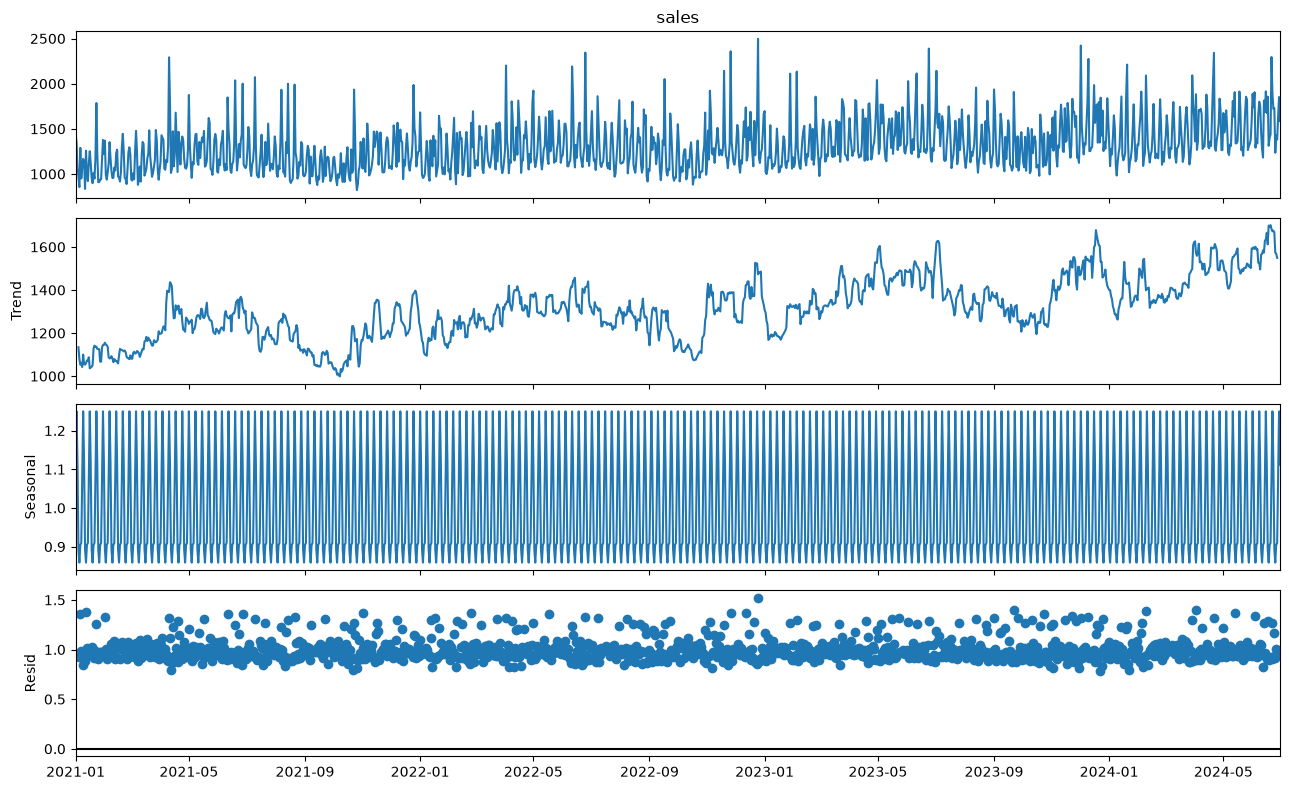

In [3]:
result = seasonal_decompose(df['sales'], model='multiplicative', period=7)
result.plot(); plt.gcf().set_size_inches(13,8); plt.tight_layout(); plt.show()

## Sazonalidade semanal e anual

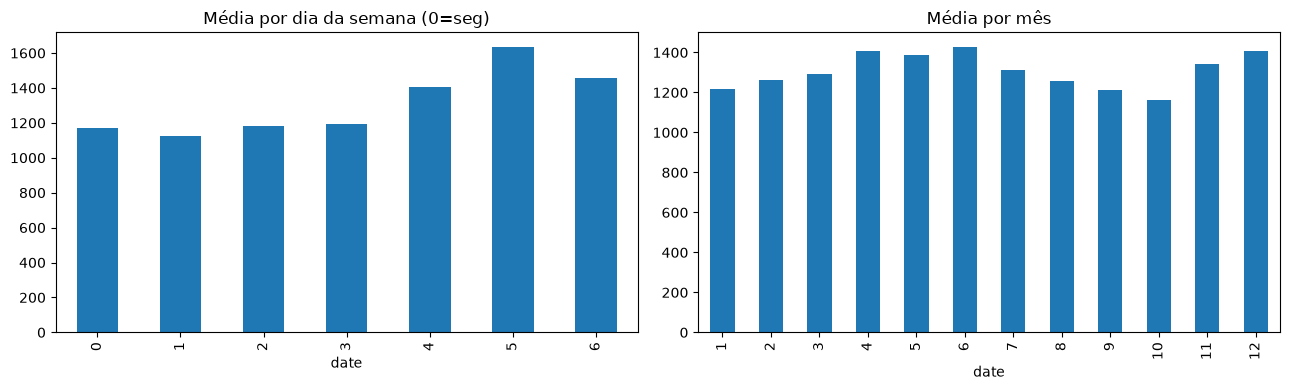

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
df.groupby(df.index.dayofweek)['sales'].mean().plot(kind='bar', ax=ax[0], title='Média por dia da semana (0=seg)')
df.groupby(df.index.month)['sales'].mean().plot(kind='bar', ax=ax[1], title='Média por mês')
plt.tight_layout(); plt.show()

## Efeito de promoções e feriados

In [5]:
print('Venda média com/sem promoção:')
print(df.groupby('promo')['sales'].mean())
print('\nVenda média em feriado vs. dia normal:')
print(df.groupby('holiday')['sales'].mean())

Venda média com/sem promoção:
promo
0    1267.158716
1    1716.903226
Name: sales, dtype: float64

Venda média em feriado vs. dia normal:
holiday
0    1303.491172
1    1605.806452
Name: sales, dtype: float64


## Autocorrelação (ACF / PACF)

Guiam as ordens dos modelos ARIMA/SARIMA — picos em lags múltiplos de 7 indicam sazonalidade semanal.

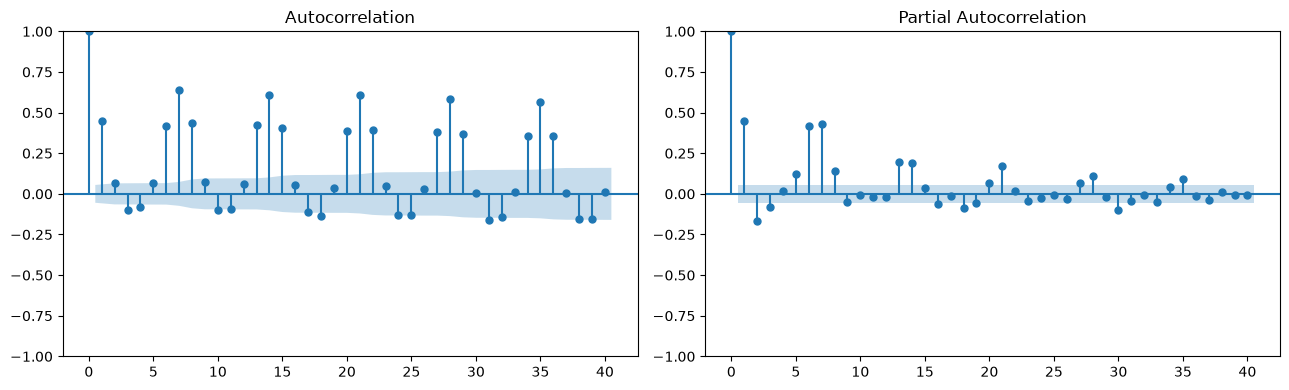

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
plot_acf(df['sales'], lags=40, ax=ax[0])
plot_pacf(df['sales'], lags=40, ax=ax[1])
plt.tight_layout(); plt.show()

## Insights de negócio

1. **Tendência de crescimento** consistente — a base de vendas sobe ~8% ao ano; o modelo precisa capturar tendência (diferenciação no ARIMA, `trend` no Prophet).
2. **Sazonalidade semanal forte** — fim de semana vende bem mais; justifica o componente semanal (SARIMA m=7, `weekly_seasonality` no Prophet, feature `dayofweek` no XGBoost).
3. **Sazonalidade anual** com pico em nov/dez (Black Friday + Natal) — termos de Fourier / `yearly_seasonality`.
4. **Promoções e feriados elevam vendas** — devem entrar como **regressores exógenos** (SARIMAX, Prophet add_regressor, features no XGBoost).
5. **ACF com picos em múltiplos de 7** confirma a sazonalidade semanal e orienta as ordens sazonais.

Esses achados definem as features (Etapa 4) e a configuração dos modelos (Etapa 5).